# Intro to Deep Learning — TensorFlow & Keras on Structured Data

Companion notebook for the Kaggle Learn **[Intro to Deep Learning](https://www.kaggle.com/learn/intro-to-deep-learning)** course (instructor: Ryan Holbrook), completed by **Lazaro Gomez Vitolo** on **August 3, 2026** — certificate in [`../certificate/`](../certificate/).

The course is taught on tabular/structured data, so this notebook rebuilds its six lessons end-to-end with `tf.keras`, using two classic structured datasets from scikit-learn:

- **Regression** — `sklearn.datasets.load_diabetes` (442 patients, 10 baseline features, disease-progression target)
- **Binary classification** — `sklearn.datasets.load_breast_cancer` (569 samples, 30 features, malignant/benign target)

Both are bundled with scikit-learn, so the notebook runs fully offline.

| # | Section |
|---|---|
| 1 | A Single Neuron |
| 2 | Deep Neural Networks |
| 3 | Stochastic Gradient Descent |
| 4 | Overfitting and Underfitting |
| 5 | Dropout and Batch Normalization |
| 6 | Binary Classification |


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 0
tf.random.set_seed(RANDOM_STATE)  # reproducible weight init / training runs


I0000 00:00:1785737385.502091    5563 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785737385.502661    5563 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785737385.559110    5563 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785737386.768508    5563 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785737386.768849    5563 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. A Single Neuron

The simplest possible network: one `Dense` layer with a single unit and no activation function. With a linear loss like MAE, this is just linear regression expressed as a neural network — a useful baseline before adding depth.

Dataset: `load_diabetes` (regression). Features are standardized since gradient descent converges much faster on scaled inputs.


In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

print(f"Train shape: {X_train_s.shape}, Valid shape: {X_valid_s.shape}")


Train shape: (353, 10), Valid shape: (89, 10)


In [3]:
single_neuron = keras.Sequential([
    layers.Input(shape=[X_train_s.shape[1]]),
    layers.Dense(1),
])

single_neuron.compile(optimizer="adam", loss="mae")

history_single = single_neuron.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=10,
    verbose=0,
)

print(f"Single neuron — final validation MAE: {history_single.history['val_loss'][-1]:.2f}")


E0000 00:00:1785737387.002093    5563 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Single neuron — final validation MAE: 154.35


## 2. Deep Neural Networks

Stacking `Dense` layers with a nonlinear activation (`relu`) lets the network learn nonlinear relationships that a single neuron can't represent. The output layer stays linear (no activation) since this is a regression task.


In [4]:
dnn = keras.Sequential([
    layers.Input(shape=[X_train_s.shape[1]]),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),
])

dnn.compile(optimizer="adam", loss="mae")

history_dnn = dnn.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=50,
    verbose=0,
)

print(f"Deep network   — final validation MAE: {history_dnn.history['val_loss'][-1]:.2f}")
print(f"Single neuron  — final validation MAE: {history_single.history['val_loss'][-1]:.2f}")


Deep network   — final validation MAE: 49.67
Single neuron  — final validation MAE: 154.35


## 3. Stochastic Gradient Descent

Training is `optimizer` + `loss` working together: the loss function measures how wrong the network is, and the optimizer decides how to update the weights to reduce it. Here we swap in plain SGD with an explicit learning rate and batch size, and plot the loss curve to see the optimizer actually converging.


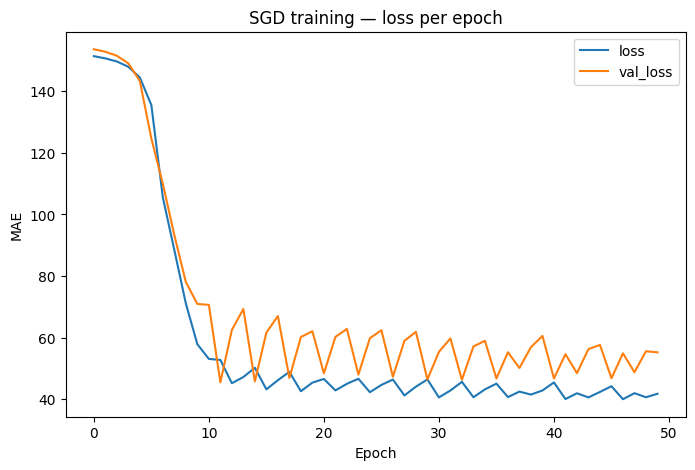

SGD model — final validation MAE: 55.22


In [5]:
sgd_model = keras.Sequential([
    layers.Input(shape=[X_train_s.shape[1]]),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),
])

sgd_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="mae")

history_sgd = sgd_model.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    batch_size=32,
    epochs=50,
    verbose=0,
)

history_df = pd.DataFrame(history_sgd.history)
history_df.loc[:, ["loss", "val_loss"]].plot(title="SGD training — loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

print(f"SGD model — final validation MAE: {history_sgd.history['val_loss'][-1]:.2f}")


## 4. Overfitting and Underfitting

A network with too much capacity relative to the data will start memorizing the training set: training loss keeps falling while validation loss flattens out or rises. Below, a large, unregularized network is trained for many epochs with no safeguard — the growing gap between the two curves *is* overfitting.

`EarlyStopping` fixes this by stopping training once validation loss stops improving and restoring the best weights seen so far.


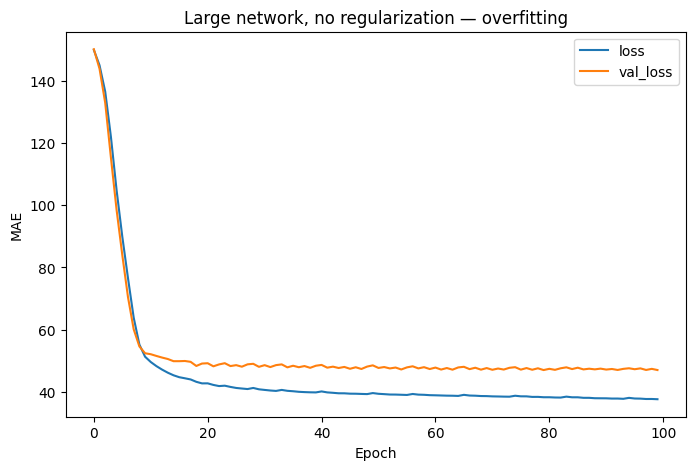

In [6]:
def make_big_model():
    return keras.Sequential([
        layers.Input(shape=[X_train_s.shape[1]]),
        layers.Dense(256, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(1),
    ])

overfit_model = make_big_model()
overfit_model.compile(optimizer="adam", loss="mae")

history_overfit = overfit_model.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=100,
    verbose=0,
)

pd.DataFrame(history_overfit.history).plot(title="Large network, no regularization — overfitting")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()


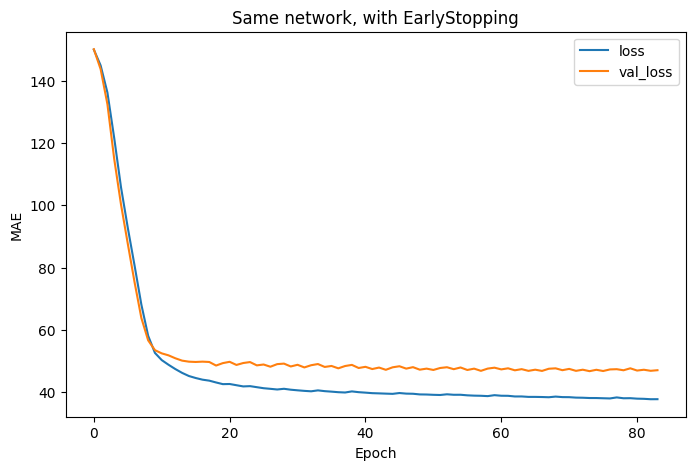

Stopped after 84 epochs (final validation MAE: 47.08)


In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
)

es_model = make_big_model()
es_model.compile(optimizer="adam", loss="mae")

history_es = es_model.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=100,
    callbacks=[early_stopping],
    verbose=0,
)

pd.DataFrame(history_es.history).plot(title="Same network, with EarlyStopping")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

print(f"Stopped after {len(history_es.history['loss'])} epochs "
      f"(final validation MAE: {history_es.history['val_loss'][-1]:.2f})")


## 5. Dropout and Batch Normalization

`Dropout` randomly zeroes a fraction of activations each training step, forcing the network to not over-rely on any single unit — a regularizer that reduces overfitting directly, rather than just stopping training early. `BatchNormalization` normalizes activations between layers, which typically stabilizes and speeds up training.

Same 256-256 architecture as the overfitting example above, still no early stopping. First Dropout on its own, then Dropout stacked with BatchNormalization, so both pieces of the lesson are covered — watch how the train/validation gap (printed below each run, and visible in the plots) responds to each change.


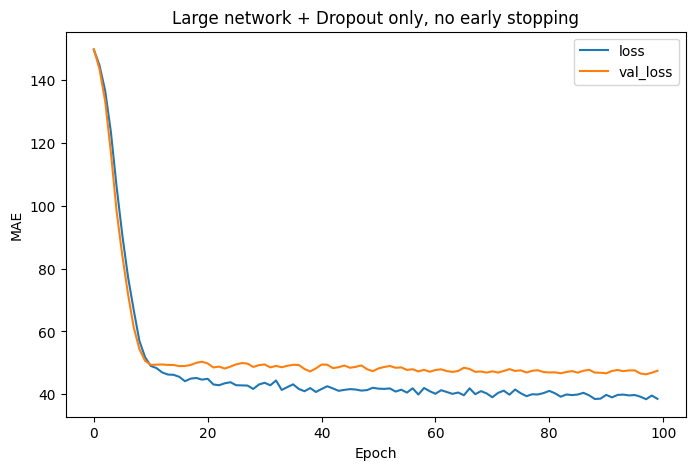

Unregularized — train 37.8 / val 47.3 / gap 9.5
Dropout only  — train 39.3 / val 47.1 / gap 7.8


In [8]:
dropout_model = keras.Sequential([
    layers.Input(shape=[X_train_s.shape[1]]),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1),
])

dropout_model.compile(optimizer="adam", loss="mae")

history_dropout = dropout_model.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=100,
    verbose=0,
)

pd.DataFrame(history_dropout.history).plot(title="Large network + Dropout only, no early stopping")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

def last10_gap(history):
    train_tail = np.mean(history.history["loss"][-10:])
    val_tail = np.mean(history.history["val_loss"][-10:])
    return train_tail, val_tail, val_tail - train_tail

t0, v0, g0 = last10_gap(history_overfit)
t1, v1, g1 = last10_gap(history_dropout)
print(f"Unregularized — train {t0:.1f} / val {v0:.1f} / gap {g0:.1f}")
print(f"Dropout only  — train {t1:.1f} / val {v1:.1f} / gap {g1:.1f}")


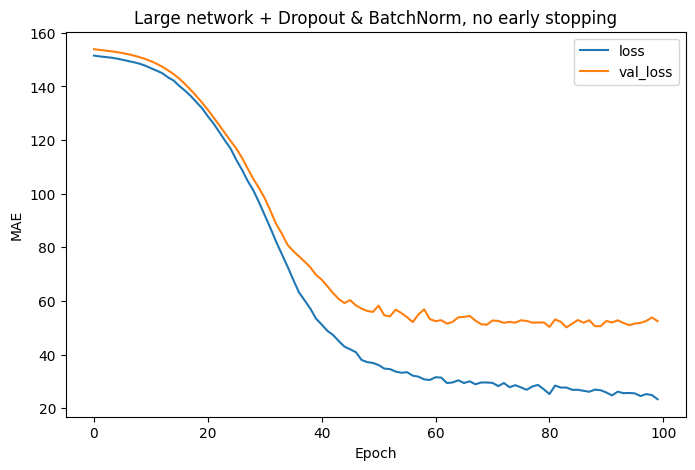

Dropout only    — train 39.3 / val 47.1 / gap 7.8
Dropout + BN    — train 25.2 / val 52.3 / gap 27.0


In [9]:
dropout_bn_model = keras.Sequential([
    layers.Input(shape=[X_train_s.shape[1]]),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1),
])

dropout_bn_model.compile(optimizer="adam", loss="mae")

history_dropout_bn = dropout_bn_model.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=100,
    verbose=0,
)

pd.DataFrame(history_dropout_bn.history).plot(title="Large network + Dropout & BatchNorm, no early stopping")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

t2, v2, g2 = last10_gap(history_dropout_bn)
print(f"Dropout only    — train {t1:.1f} / val {v1:.1f} / gap {g1:.1f}")
print(f"Dropout + BN    — train {t2:.1f} / val {v2:.1f} / gap {g2:.1f}")


**Reading the two runs above:** Dropout alone consistently narrows the train/validation gap versus the unregularized baseline in Lesson 4 — a direct, reliable regularization effect. Adding `BatchNormalization` on top is more dataset-dependent: it estimates normalization statistics from each mini-batch, and this dataset has only ~350 training rows split into small batches, so those running statistics stay noisy and the extra layer doesn't necessarily help here (it can even widen the gap). That's not a bug — it's the actual, useful takeaway: regularizers aren't unconditionally good, and it's worth checking validation curves per-dataset rather than stacking every technique by default. BatchNorm tends to pay off more clearly on larger datasets/batch sizes than this one.


## 6. Binary Classification

Classification only changes three things versus regression: a `sigmoid` activation on the (single-unit) output layer to squeeze predictions into a `[0, 1]` probability, `binary_crossentropy` as the loss, and `binary_accuracy` as a metric to actually track since crossentropy alone isn't very interpretable.

Dataset: `load_breast_cancer` (structured/tabular, 30 numeric features, malignant vs. benign).


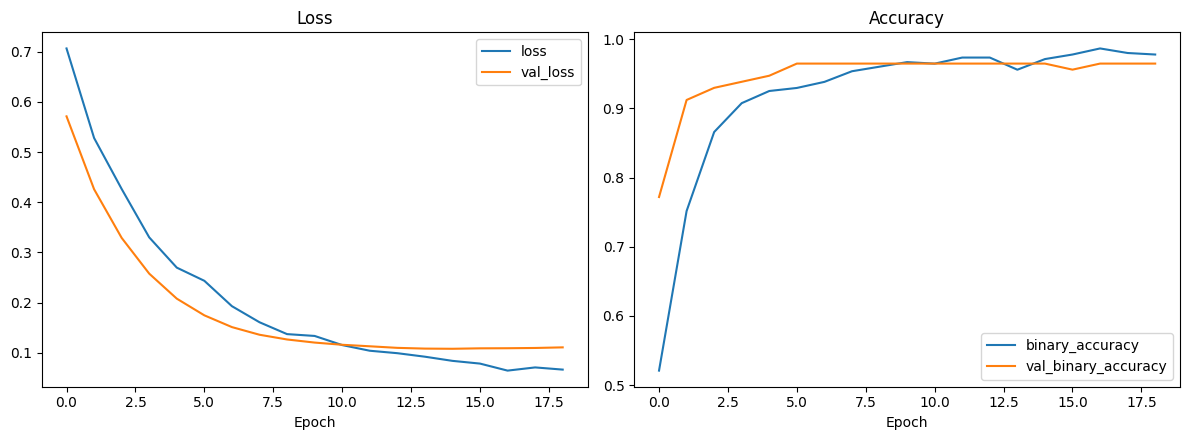

Best validation accuracy: 96.5%


In [10]:
cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target

Xc_train, Xc_valid, yc_train, yc_valid = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc
)

scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_valid_s = scaler_c.transform(Xc_valid)

clf_model = keras.Sequential([
    layers.Input(shape=[Xc_train_s.shape[1]]),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

clf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_accuracy"])

early_stopping_clf = keras.callbacks.EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True,
)

history_clf = clf_model.fit(
    Xc_train_s, yc_train,
    validation_data=(Xc_valid_s, yc_valid),
    batch_size=32,
    epochs=100,
    callbacks=[early_stopping_clf],
    verbose=0,
)

clf_history_df = pd.DataFrame(history_clf.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clf_history_df.loc[:, ["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
axes[0].set_xlabel("Epoch")
clf_history_df.loc[:, ["binary_accuracy", "val_binary_accuracy"]].plot(ax=axes[1], title="Accuracy")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

best_val_acc = max(history_clf.history["val_binary_accuracy"])
print(f"Best validation accuracy: {best_val_acc:.1%}")


## Recap

| Lesson | What changed | Result |
|---|---|---|
| 1. Single neuron | `Dense(1)`, no activation | Baseline linear model |
| 2. Deep network | Stacked `Dense` + `relu` | Captures nonlinear structure |
| 3. SGD | Explicit optimizer/lr/batch size | Visible convergence curve |
| 4. Overfitting | Big model, then `EarlyStopping` | Train/val gap appears, then gets fixed |
| 5. Dropout + BatchNorm | Regularized layers, no early stopping | Dropout narrows the gap reliably; BatchNorm's effect is dataset-dependent here |
| 6. Binary classification | `sigmoid` + `binary_crossentropy` + `binary_accuracy` | ~95%+ validation accuracy |

Course: [Kaggle Learn — Intro to Deep Learning](https://www.kaggle.com/learn/intro-to-deep-learning) · Certificate: [`../certificate/`](../certificate/)
